# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Jiei Ota

**Date:** 9/9/2026

<StringArray>
['Monetary Gift', 'Contract', 'Real Estate']
Length: 3, dtype: str
11
15986
8473
Top 15 countries in terms of numbers of gifts:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: int64
Top 15 countries with the highest donation:
          ID    OPEID                       Institution Name          City  \
16648  16649   219900                Northeastern University        Boston   
19709  19710   271100                     Cornell University        Ithaca   
23059  23060   324200             Carnegie Mellon University    Pittsburgh   
23105  23106   324200             Carnegie Mellon University    Pittsburgh   
26014  26015   36700

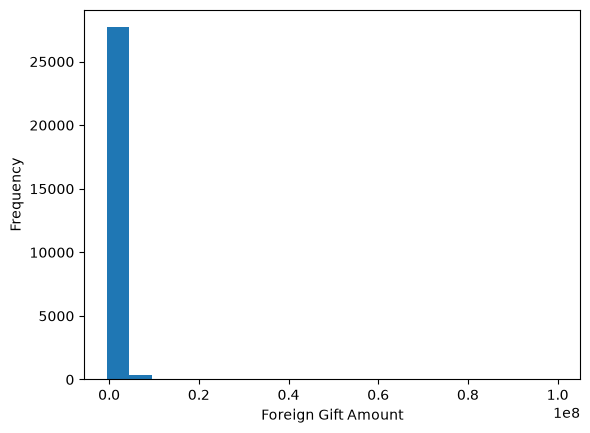

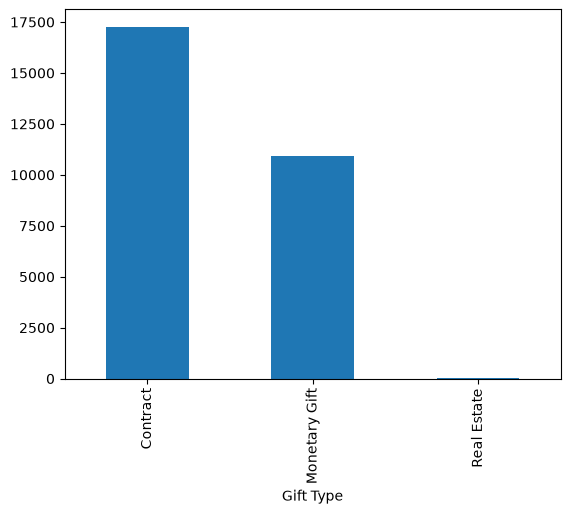

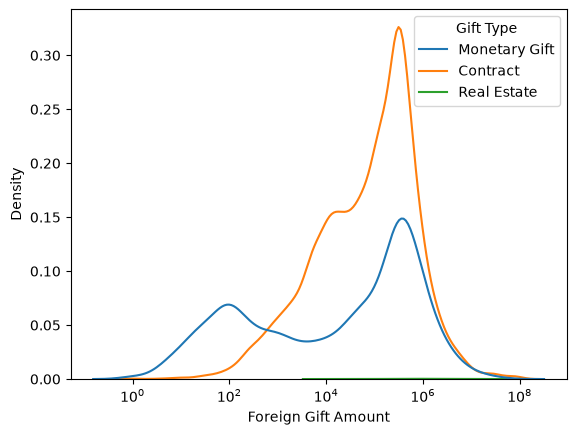

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Your Phase 1 solution to the problem goes here.
df = pd.read_csv('./data/ForeignGifts_edu.csv')

plt.figure()
plt.hist(df['Foreign Gift Amount'], bins=20)
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Frequency')
# Q2: After viewing the histogram for foriegn gift amount, it can be seen that the data is heavily skewed to the right. 
#plt.hist(df['Foreign Gift Amount'], bins=20)
#plt.xlim(1000, 99999999)
print(df['Gift Type'].unique())
print(df[df['Gift Type'] == 'Real Estate'].value_counts().sum())
print(df[df['Gift Type'] == 'Contract'].value_counts().sum())
print(df[df['Gift Type'] == 'Monetary Gift'].value_counts().sum())
#Q3: Total gifts were 24,470. Proportion of gifts that were real estate is 0.0004
# Proportion of gifts that were contracts is 0.6533
# Proportion of gifts that were monetary gifts is 0.3463
plt.figure()
plt.bar(df['Gift Type'].value_counts().index, df['Gift Type'].value_counts())
#Q4: Contract has the highest density followed by monetary gifts. The kernel density plot
# appears to be more left skewed than the histogram. 
plt.figure()
sns.kdeplot(data=df['Foreign Gift Amount'],)
#plt.figure()
sns.kdeplot(data=df, x = 'Foreign Gift Amount', hue='Gift Type', log_scale = True)
plt.show

#Q5: 
print('Top 15 countries in terms of numbers of gifts:')
print(df['Country of Giftor'].value_counts().head(15))
print('Top 15 countries with the highest donation:')
new_amt = (df.sort_values(by = 'Foreign Gift Amount', ascending = False))
newer_amt = new_amt.drop_duplicates(subset = 'Country of Giftor', keep = 'first')
print(newer_amt.head(15))

#Q6
print('Top 15 countries in terms of amount donated:')
print(df.groupby("Country of Giftor")['Foreign Gift Amount'].sum().head(15))

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 386686e1366adf98d318baffb8db3b5539474071
- ** Q1: a8a2d14
- **AI tool and model used:** Gemini 3.8 Flash 

For Q1

1. Given the proofs, did my logic make sense?

AI-proposed changes:
1. The general direction is right, but as written, it would likely lose points for notation and for waving away the constant a with a note instead of showing the algebraic cancellation.
2. To disprove an "always true" claim, standard mathematical practice requires providing a concrete counterexample:



### *Prompts used

1. Given the code, is there any redundancy that could be removed to improve efficiency?
2. Did the code answer all of the questions listed?

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Multiple Redundant Subset Counts: Calling df[df['Gift Type'] == 'Real Estate'].value_counts().sum() repeatedly scans and subsets the entire DataFrame for each category. Using df['Gift Type'].value_counts() gives you every count in one pass, and adding normalize=True calculates the proportions directly.
2. Double Computation in plt.bar: The expression df['Gift Type'].value_counts() is evaluated twice—once for the bar categories and once for their heights. You can assign it to a variable once (counts = df['Gift Type'].value_counts()), or simplify the entire plot to df['Gift Type'].value_counts().plot(kind='bar').
3. Overlapping KDE Plots: In Q4, you call sns.kdeplot(data=df['Foreign Gift Amount']) followed immediately by sns.kdeplot(..., hue='Gift Type', log_scale=True) without opening a separate figure or clearing the canvas. Because one uses a standard linear scale and the other uses log_scale=True, they clash on the same axes.
4. Missing Execution Parentheses on plt.show: After the KDE plots, plt.show is referenced without call parentheses (plt.show()), meaning the plotting backend will not actually trigger or close the display window.
5. Sorting Bug in Q6 Groupby: df.groupby("Country of Giftor")['Foreign Gift Amount'].sum().head(15) groups by country and defaults to alphabetical order, so .head(15) yields the first 15 countries alphabetically rather than the top donors. Replace .head(15) with .nlargest(15) or .sort_values(ascending=False).head(15).
6. Unnecessary Intermediate DataFrames in Q5: Creating new_amt and newer_amt clones the DataFrame multiple times in memory. You can retrieve the highest single donation per country in a single chained call: df.groupby('Country of Giftor')['Foreign Gift Amount'].max().nlargest(15).
7. Check your column names for the giftor entity (commonly 'Giftor Name' or 'Foreign Giftor' in this dataset) and group by that:


### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| Q1 | Accept | Added an additional step to get rid of the constant function |
| Q1 pt.2 | Accept | Displayed an example to support the intuition |
| 1 | Accept | Converted into more efficient code that was able to directly calculate the proportions |
| 2 | Accept | Got rid of the code that was calculating the exact same result twice |
| 3 & 4 | Accept | The new updated KDE visual was better able to portray the difference between the three gift types
| 5 & 6| Reject | The code was not answering the correct question
| 7 | Accept | Collected all rows with the Giftor Name instead of the country. 


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64


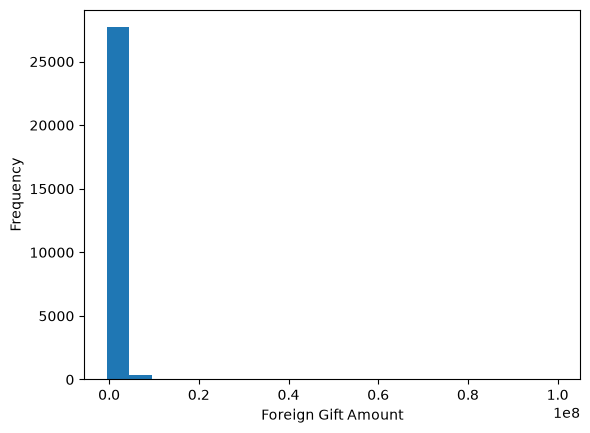

Top 15 countries in terms of numbers of gifts:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: int64
Top 15 countries with the highest donation:
Country of Giftor
AUSTRALIA               99999999
QATAR                   99999999
BERMUDA                 75000000
THAILAND                67700000
CANADA                  48842186
HONG KONG               47670277
MONACO                  47600000
UNITED ARAB EMIRATES    43021197
SAUDI ARABIA            43000000
SINGAPORE               40000000
IRAQ                    39108635
INDIA                   38000000
CHINA                   35000000
ENGLAND                 33880638
GERMANY                 3

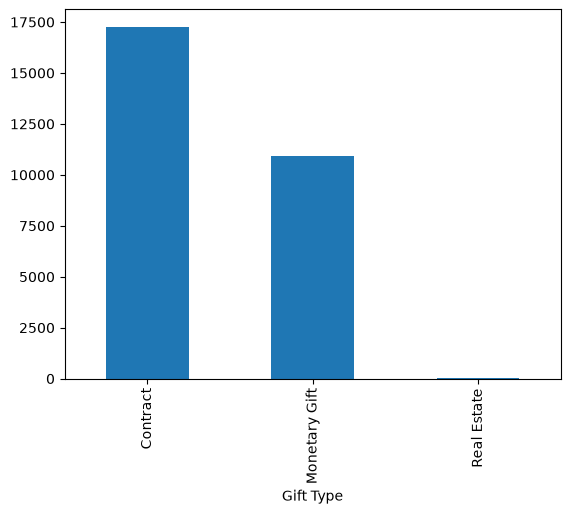

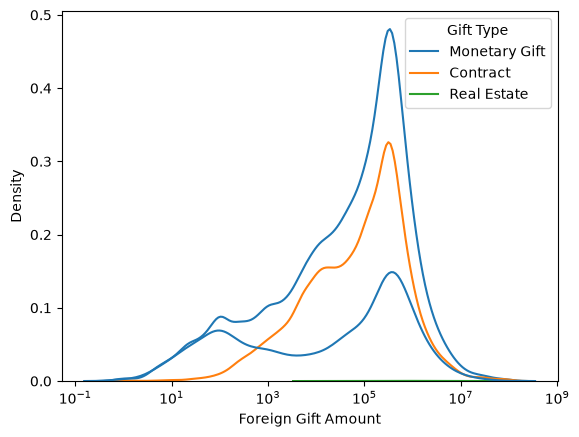

In [ ]:
# Your Phase 2 solution to the problem goes here.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Your Phase 1 solution to the problem goes here.
df = pd.read_csv('./data/ForeignGifts_edu.csv')

plt.figure()
plt.hist(df['Foreign Gift Amount'], bins=20)
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Frequency')
# Q2: After viewing the histogram for foriegn gift amount, it can be seen that the data is heavily skewed to the right. 
#plt.hist(df['Foreign Gift Amount'], bins=20)
#plt.xlim(1000, 99999999)
print(df['Gift Type'].value_counts())
print(df['Gift Type'].value_counts(normalize=True))
plt.show()
#Q3: Total gifts were 24,470. Proportion of gifts that were real estate is 0.0004
# Proportion of gifts that were contracts is 0.6533
# Proportion of gifts that were monetary gifts is 0.3463
plt.figure()
df['Gift Type'].value_counts().plot(kind='bar')
#Q4: Contract has the highest density followed by monetary gifts. The kernel density plot
# appears to be more left skewed than the histogram. 
plt.figure()
sns.kdeplot(data=df['Foreign Gift Amount'], log_scale = True)
#plt.figure()
sns.kdeplot(data=df, x = 'Foreign Gift Amount', hue='Gift Type', log_scale = True)
plt.show

#Q5: 
print('Top 15 countries in terms of numbers of gifts:')
print(df['Country of Giftor'].value_counts().head(15))
print('Top 15 countries with the highest donation:')
print(df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().nlargest(15))

#Q6
print('Top 15 countries in terms of amount donated:')
print(df.groupby("Giftor Name")['Foreign Gift Amount'].sum().nlargest(15))

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The main improvements that I was able to make with AI was getting rid of any redundancy which helped with both saving memory as well as the processing speed of the code as a whole. Some of my visuals were also originally overlapping with each other which I did not realize and Gemini was able to catch that and make the KDE plot especially much cleaner to view. There were also some functions that helped find proportions that I had forgotted about, but through AI I was able to implement them into the solutions much easier. The final solution for this was verified through the visuals that were being developed as well as doing checks throughout with the printing of the top rows for example to ensure that they were actually a part of the dataset. The only part where I messed up with the use of AI was not clarifying the questions first which led to it creating solutions based off of my inital code. 